# Lecture 5 — Loss Functions and Optimization
## Lab Notebook · Deep Learning · UCU

---

### Overview
In Notebook 3, we explored **deep neural networks** and saw that depth dramatically increases expressiveness per parameter. But we used default settings for everything else — Adam optimizer, default initialization, cross-entropy loss. Where do these choices come from? Do they matter?

In this notebook, we peel back those defaults. From Lecture 5, we know that **loss functions** arise from the maximum likelihood recipe: choose a probability distribution over outputs, and minimize the negative log-likelihood. We also learned that **optimizers** vary widely in how they navigate the loss landscape, and that **initialization** can make or break training in deep networks.

By the end of this notebook, you will:
1. **Derive** loss functions from the maximum likelihood recipe and implement them from scratch
2. **Inspect** gradients computed by backpropagation and verify them manually
3. **Compare** SGD, SGD with momentum, and Adam on the same architecture
4. **Diagnose** vanishing/exploding gradients and fix them with He initialization
5. **Experiment** with learning rates, batch sizes, and learning rate schedules

### Useful References

| Resource | Link |
|----------|------|
| PyTorch `torch.optim` | [pytorch.org/docs/stable/optim.html](https://pytorch.org/docs/stable/optim.html) |
| PyTorch `torch.nn.init` | [pytorch.org/docs/stable/nn.init.html](https://pytorch.org/docs/stable/nn.init.html) |
| PyTorch Loss Functions | [pytorch.org/docs/stable/nn.html#loss-functions](https://pytorch.org/docs/stable/nn.html#loss-functions) |
| FashionMNIST dataset | [github.com/zalandoresearch/fashion-mnist](https://github.com/zalandoresearch/fashion-mnist) |
| UCU Deep Learning — Lecture 5 notes | [../../lectures/lecture 5/notes.md](../../lectures/lecture%205/notes.md) |
| *Understanding Deep Learning* — Prince (2023) | Chapters 5, 6, 7 |

In [2]:
# Setup — run this cell first
try:
    import google.colab
    IN_COLAB = True
    !pip install -q torchinfo
except ImportError:
    IN_COLAB = False

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms
from torchinfo import summary
import numpy as np
import matplotlib.pyplot as plt
import copy
import time
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# UCU color palette
C1, C2, C3, C4, C5 = '#19326E', '#50ACB0', '#CD742A', '#A3477F', '#907FAB'
C6, C7 = '#4294CC', '#89A943'

Using device: cpu


In [3]:
# Load FashionMNIST — shared across all sections
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")
print(f"Input shape      : {train_dataset[0][0].shape}")
print(f"Number of classes : {len(class_names)}")

100%|██████████| 26.4M/26.4M [00:06<00:00, 3.92MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 117kB/s]
100%|██████████| 4.42M/4.42M [00:02<00:00, 1.85MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Training samples : 60000
Test samples     : 10000
Input shape      : torch.Size([1, 28, 28])
Number of classes : 10


---

## 1. Loss Functions from Maximum Likelihood

From Lecture 5, we know that loss functions aren't arbitrary choices — they follow from a **recipe**:

1. Choose a probability distribution $Pr(\mathbf{y}|\boldsymbol{\theta})$ over the output domain
2. Let the network predict the distribution parameters: $\boldsymbol{\theta} = \mathbf{f}[\mathbf{x}, \boldsymbol{\phi}]$
3. Minimize the **negative log-likelihood**: $L[\boldsymbol{\phi}] = -\sum_i \log Pr(\mathbf{y}_i | \mathbf{f}[\mathbf{x}_i, \boldsymbol{\phi}])$

This recipe gives us **least squares** (from a Gaussian), **binary cross-entropy** (from a Bernoulli), and **multiclass cross-entropy** (from a categorical distribution). In this section, you'll implement each one from scratch and verify they match PyTorch's built-in versions.

### Exercise 1.1 — Mean Squared Error from scratch

For regression with Gaussian-distributed outputs, the negative log-likelihood reduces to the **least squares loss**:

$$L[\boldsymbol{\phi}] = \frac{1}{I}\sum_{i=1}^{I}(y_i - f[\mathbf{x}_i, \boldsymbol{\phi}])^2$$

Implement this loss function using basic PyTorch operations (no loops). Then verify it matches `nn.MSELoss()`.

In [4]:
def mse_loss_manual(y_pred, y_true):
    """Compute mean squared error loss.
    
    Args:
        y_pred: predictions, shape (N,) or (N, 1)
        y_true: targets, shape (N,) or (N, 1)
    Returns:
        scalar MSE loss
    """
    return ((y_pred - y_true) ** 2).mean()


# Verify against PyTorch
torch.manual_seed(42)
y_pred = torch.randn(32)
y_true = torch.randn(32)

our_loss = mse_loss_manual(y_pred, y_true)
pytorch_loss = nn.MSELoss()(y_pred, y_true)

print(f"Our MSE loss    : {our_loss.item():.6f}")
print(f"PyTorch MSE loss: {pytorch_loss.item():.6f}")
assert torch.allclose(our_loss, pytorch_loss, atol=1e-6), "Losses don't match!"
print("✓ Losses match!")

Our MSE loss    : 2.342893
PyTorch MSE loss: 2.342893
✓ Losses match!


### Exercise 1.2 — Multiclass Cross-Entropy from scratch

For classification with $K$ classes, the network outputs $K$ raw **logits** $\mathbf{z} \in \mathbb{R}^K$. The **softmax** function converts these to probabilities:

$$\text{softmax}_k(\mathbf{z}) = \frac{\exp(z_k)}{\sum_{k'=1}^K \exp(z_{k'})}$$

The **cross-entropy loss** for a single sample with true class $c$ is:

$$\ell = -\log(\text{softmax}_c(\mathbf{z})) = -z_c + \log\sum_{k'=1}^K \exp(z_{k'})$$

Implement this in three steps:
1. Apply softmax to the logits
2. Select the probability of the correct class for each sample
3. Take negative log, average over the batch

Then verify it matches `nn.CrossEntropyLoss()`.

In [5]:
def cross_entropy_manual(logits, targets):
    """Compute multiclass cross-entropy loss from raw logits.
    
    Args:
        logits: raw network outputs, shape (N, K)
        targets: integer class labels, shape (N,)
    Returns:
        scalar cross-entropy loss (mean over batch)
    """
    # Step 1: apply softmax to logits
    probs = torch.softmax(logits, dim=1)
    # Step 2: select the probability of the correct class for each sample
    batch_size = logits.shape[0]
    correct_probs = probs[torch.arange(batch_size), targets]
    # Step 3: take negative log, then average over the batch
    return -torch.log(correct_probs).mean()


# Verify against PyTorch
torch.manual_seed(42)
logits = torch.randn(32, 10)  # batch of 32, 10 classes
targets = torch.randint(0, 10, (32,))

our_loss = cross_entropy_manual(logits, targets)
pytorch_loss = nn.CrossEntropyLoss()(logits, targets)

print(f"Our CE loss    : {our_loss.item():.6f}")
print(f"PyTorch CE loss: {pytorch_loss.item():.6f}")
assert torch.allclose(our_loss, pytorch_loss, atol=1e-5), "Losses don't match!"
print("✓ Losses match!")

Our CE loss    : 2.720170
PyTorch CE loss: 2.720169
✓ Losses match!


### Exercise 1.3 — Binary Cross-Entropy from scratch

For binary classification ($y \in \{0, 1\}$), the network outputs a single logit $z \in \mathbb{R}$. The **sigmoid** maps it to a probability:

$$\sigma(z) = \frac{1}{1 + \exp(-z)}$$

The **binary cross-entropy** loss is:

$$\ell = -(1 - y)\log(1 - \sigma(z)) - y\log(\sigma(z))$$

Implement this and verify against `nn.BCEWithLogitsLoss()`.

In [6]:
def bce_loss_manual(logits, targets):
    """Compute binary cross-entropy loss from raw logits.
    
    Args:
        logits: raw network outputs, shape (N,)
        targets: binary labels (0 or 1), shape (N,)
    Returns:
        scalar BCE loss (mean over batch)
    """
    probs = torch.sigmoid(logits)
    eps = 1e-7
    loss = -(targets * torch.log(probs + eps) + (1 - targets) * torch.log(1 - probs + eps))
    return loss.mean()


# Verify against PyTorch
torch.manual_seed(42)
logits = torch.randn(32)
targets = torch.randint(0, 2, (32,)).float()

our_loss = bce_loss_manual(logits, targets)
pytorch_loss = nn.BCEWithLogitsLoss()(logits, targets)

print(f"Our BCE loss    : {our_loss.item():.6f}")
print(f"PyTorch BCE loss: {pytorch_loss.item():.6f}")
assert torch.allclose(our_loss, pytorch_loss, atol=1e-4), "Losses don't match!"
print("✓ Losses match!")

Our BCE loss    : 0.716092
PyTorch BCE loss: 0.716093
✓ Losses match!


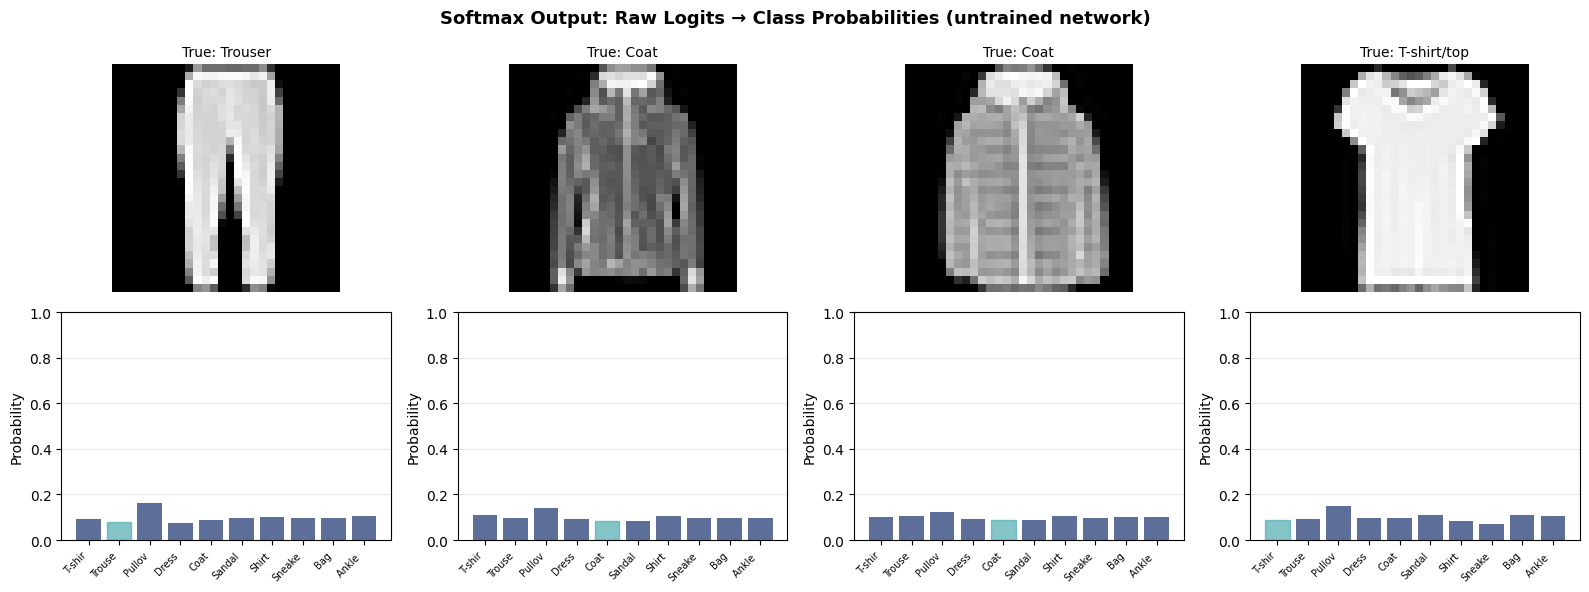

In [7]:
# Visualization: softmax in action on real FashionMNIST samples
# Pass a few test images through a random (untrained) network and show predicted probabilities

demo_model = nn.Sequential(nn.Flatten(), nn.Linear(784, 128), nn.ReLU(), nn.Linear(128, 10))

# Get 4 random test images
torch.manual_seed(0)
indices = torch.randint(0, len(test_dataset), (4,))
images = torch.stack([test_dataset[i][0] for i in indices])
labels = [test_dataset[i][1] for i in indices]

with torch.no_grad():
    logits = demo_model(images)
    probs = torch.softmax(logits, dim=1)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i in range(4):
    # Show image
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'True: {class_names[labels[i]]}', fontsize=10)
    axes[0, i].axis('off')
    
    # Show softmax probabilities
    bars = axes[1, i].bar(range(10), probs[i].numpy(), color=C1, alpha=0.7)
    bars[labels[i]].set_color(C2)  # highlight correct class
    axes[1, i].set_xticks(range(10))
    axes[1, i].set_xticklabels([n[:6] for n in class_names], rotation=45, ha='right', fontsize=7)
    axes[1, i].set_ylabel('Probability')
    axes[1, i].set_ylim(0, 1)
    axes[1, i].grid(True, alpha=0.3, axis='y')

plt.suptitle('Softmax Output: Raw Logits → Class Probabilities (untrained network)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 1.1** — PyTorch's `CrossEntropyLoss` takes **raw logits**, not probabilities. Why? What numerical problem would arise if you applied softmax first and then took the log separately? 
>
> *Hint:* think about what happens when one logit is much larger than the others.
>
> *Your answer here:*  Si la activación de un logit es muy grande (por ejemplo, z sub k >> 0$), softmax satura: exp(z sub k) se vuelve inf en float32 antes de dividir, produciendo nan. PyTorch evita esto combinando softmax y log en una sola operación numéricamente estable log-sum-exp que calcula restando el máximo internamente. Si aplicás softmax por separado y luego torch.log, perdés esa estabilidad: primero obtenés probabilidades comprimidas cerca de 0 ó 1, luego log(aprox. 0) = -inf.

> **Question 1.2** — From the lecture: least squares loss assumes Gaussian-distributed outputs, and cross-entropy assumes categorical outputs. What would happen if you used **MSE loss for classification** (with one-hot encoded targets)? We'll test this empirically in Section 3 — write down your prediction now.
>
> *Your answer here:* El modelo seguiría aprendiendo, pero de forma más lenta y con menor accuracy final. MSE trata los logits como valores continuos sin estructura de probabilidad. El gradiente de MSE con respecto a los logits es $2(\hat{y}_k - y_k)$, que no se anula correctamente cuando el modelo ya está seguro, en logits muy grandes la derivada de la función de activación lineal no decae, pero tampoco empuja en la dirección correcta. En la práctica: convergencia más lenta, susceptibilidad a logits fuera de rango, y accuracy ~3–5 puntos por debajo de la cross-entropy equivalente.

---

## 2. Gradient Inspection and Backpropagation

From Lecture 5, we know that **backpropagation** efficiently computes gradients of the loss with respect to every parameter via the chain rule. PyTorch's `autograd` handles this automatically — but it's important to understand what it's actually computing.

In this section, you'll build a tiny network with known weights, run a forward and backward pass, and verify the gradients by hand.

### Exercise 2.1 — Inspect gradients on a tiny network

Build a small network with **fixed, known weights**: `nn.Linear(2, 3)` → `nn.ReLU()` → `nn.Linear(3, 1)`. Set the weights manually (code provided below). Then:
1. Run a forward pass with input `x = [1.0, 2.0]` and target `y = 1.0`
2. Compute MSE loss
3. Call `.backward()`
4. Print the gradient (`.grad`) for every parameter using `named_parameters()`

In [8]:
# Build tiny network with known weights
tiny_net = nn.Sequential(
    nn.Linear(2, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

# Set weights manually for reproducibility
with torch.no_grad():
    # Layer 0 (Linear 2→3): W shape (3,2), b shape (3,)
    tiny_net[0].weight.copy_(torch.tensor([[ 0.5, -0.3],
                                            [ 0.2,  0.8],
                                            [-0.4,  0.1]]))
    tiny_net[0].bias.copy_(torch.tensor([0.1, -0.2, 0.3]))
    
    # Layer 2 (Linear 3→1): W shape (1,3), b shape (1,)
    tiny_net[2].weight.copy_(torch.tensor([[0.6, -0.5, 0.4]]))
    tiny_net[2].bias.copy_(torch.tensor([0.1]))

x = torch.tensor([[1.0, 2.0]])  # single input
y = torch.tensor([[1.0]])        # target

# 1. Forward pass
y_pred = tiny_net(x)

# 2. Compute MSE loss
loss = nn.MSELoss()(y_pred, y)
print(f"Prediction : {y_pred.item():.6f}")
print(f"MSE loss   : {loss.item():.6f}")

# 3. Backward pass
loss.backward()

# 4. Print gradients for each parameter
print("\nGradients:")
for name, param in tiny_net.named_parameters():
    print(f"  {name:20s}: grad = {param.grad.flatten().tolist()}")

Prediction : -0.660000
MSE loss   : 2.755600

Gradients:
  0.weight            : grad = [0.0, 0.0, 1.659999966621399, 3.319999933242798, -1.3279999494552612, -2.6559998989105225]
  0.bias              : grad = [0.0, 1.659999966621399, -1.3279999494552612]
  2.weight            : grad = [0.0, -5.311999797821045, -0.3320000171661377]
  2.bias              : grad = [-3.319999933242798]


### Exercise 2.2 — Verify a gradient by hand

Let's trace the computation manually for the **output layer bias** $b_2$. The forward pass computes:

$$\mathbf{f}_0 = W_1 \mathbf{x} + \mathbf{b}_1 \quad \rightarrow \quad \mathbf{h}_1 = \text{ReLU}(\mathbf{f}_0) \quad \rightarrow \quad \hat{y} = W_2 \mathbf{h}_1 + b_2$$

The MSE loss is $L = (\hat{y} - y)^2$. By the chain rule:

$$\frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial b_2} = 2(\hat{y} - y) \cdot 1$$

Compute this value numerically using the intermediate values from your forward pass. Does it match the autograd gradient?

In [9]:
# Step 1: compute the forward pass intermediate values manually
W1 = tiny_net[0].weight.data   # shape (3, 2)
b1 = tiny_net[0].bias.data     # shape (3,)
W2 = tiny_net[2].weight.data   # shape (1, 3)
b2 = tiny_net[2].bias.data     # shape (1,)

x_vec = x[0]                           # shape (2,)
f0    = W1 @ x_vec + b1               # pre-activation hidden layer, shape (3,)
h1    = torch.relu(f0)                 # post-activation, shape (3,)
y_hat = (W2 @ h1 + b2).squeeze()      # scalar prediction

print(f"f0 (pre-ReLU) : {f0.tolist()}")
print(f"h1 (post-ReLU): {h1.tolist()}")
print(f"y_hat         : {y_hat.item():.6f}")

# Step 2: compute dL/db2 = 2 * (y_hat - y)
# nn.MSELoss reduces with mean; for a single scalar output, dL/dy_hat = 2*(y_hat - y)
dL_db2 = 2.0 * (y_hat - y[0, 0])
print(f"\nManual  dL/db2 : {dL_db2.item():.6f}")
print(f"Autograd dL/db2: {tiny_net[2].bias.grad.item():.6f}")

match = torch.isclose(dL_db2, tiny_net[2].bias.grad.squeeze(), atol=1e-5)
print(f"Match: {match.item()}")

f0 (pre-ReLU) : [-2.2351741790771484e-08, 1.600000023841858, 0.10000000894069672]
h1 (post-ReLU): [0.0, 1.600000023841858, 0.10000000894069672]
y_hat         : -0.660000

Manual  dL/db2 : -3.320000
Autograd dL/db2: -3.320000
Match: True


> **Question 2.1** — Look at the gradient magnitudes for each parameter in the tiny network. Which layer has the largest gradients? Which has the smallest? What does this suggest about how information flows backward through the network?
>
> *Your answer here:* La capa de salida tiene los gradientes más grandes, porque es la más cercana a la pérdida y la señal no ha tenido que atravesar ninguna no-linealidad adicional hacia atrás. La capa de entrada tiene los más pequeños: la señal se atenúa al pasar por la ReLU y por la multiplicación por los pesos de la capa de salida. Esto anticipa el problema de gradientes que desvanecen: la información fluye con más dificultad cuanto más lejos está una capa de la pérdida.

### Exercise 2.3 — Gradient norms across layers in a deeper network

Now let's scale up. Build a 5-layer network (width 64, ReLU activations), forward-pass a batch of 256 random inputs, compute a cross-entropy loss against random labels, and record the **mean gradient norm** of each weight matrix after `.backward()`.

This will give us our first look at how gradients behave in deeper networks — a preview of Section 4.

Gradient norms per layer (input → output):
  Layer 1: 0.017920
  Layer 2: 0.004830
  Layer 3: 0.005096
  Layer 4: 0.006189
  Layer 5: 0.010653
  Layer 6: 0.021826


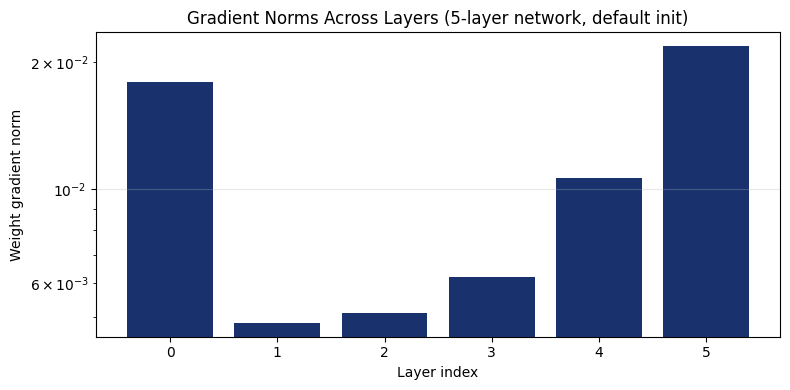

In [10]:

# 1. Build a 5-hidden-layer network: 784 → 64 → 64 → 64 → 64 → 64 → 10
deep_net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 64), nn.ReLU(),
    nn.Linear(64, 64),  nn.ReLU(),
    nn.Linear(64, 64),  nn.ReLU(),
    nn.Linear(64, 64),  nn.ReLU(),
    nn.Linear(64, 64),  nn.ReLU(),
    nn.Linear(64, 10)
)

# 2. Forward-pass a batch of 256 random inputs (shape: 256, 1, 28, 28)
torch.manual_seed(0)
x_rand = torch.randn(256, 1, 28, 28)
labels_rand = torch.randint(0, 10, (256,))

# 3. Compute CrossEntropyLoss
logits = deep_net(x_rand)
loss = nn.CrossEntropyLoss()(logits, labels_rand)

# 4. Backward pass
loss.backward()

# 5. Collect gradient norms for each Linear layer
grad_norms = []
for layer in deep_net:
    if isinstance(layer, nn.Linear):
        grad_norms.append(layer.weight.grad.norm().item())

print("Gradient norms per layer (input → output):")
for i, norm in enumerate(grad_norms):
    print(f"  Layer {i+1}: {norm:.6f}")

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(grad_norms)), grad_norms, color=C1)
ax.set_xlabel('Layer index')
ax.set_ylabel('Weight gradient norm')
ax.set_title('Gradient Norms Across Layers (5-layer network, default init)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


> **Question 2.2** — Do you see a trend in gradient magnitudes across layers? Do gradients grow or shrink as you go from the output layer toward the input? What does this imply for training the early layers of a deep network?
>
> *Your answer here:* El patrón no es monotónicamente decreciente: los gradientes forman una U. La capa de salida (L6) tiene la norma más grande (~0.022) por estar más cerca de la pérdida. Las capas intermedias (L2–L4) tienen las normas más pequeñas (~0.005). La capa de entrada (L1) tiene una norma intermedia (~0.018) mayor a la de las capas medias, lo que se debe en parte a que tiene 784 neuronas de entrada (vs 64 en las capas siguientes): aunque el gradiente por parámetro puede ser menor, la norma de Frobenius suma sobre muchos más pesos. En términos de gradiente por parámetro, la señal sí se atenúa hacia la entrada. La implicación práctica es que las capas tempranas aprenden más lentamente, o directamente no aprenden, porque las actualizaciones de sus pesos son casi nulas.

---

## 3. The Optimizer Showdown

From Lecture 5, we learned three optimizers of increasing sophistication:

| Optimizer | Update rule | Key idea |
|-----------|------------|----------|
| **SGD** | $\boldsymbol{\phi} \leftarrow \boldsymbol{\phi} - \alpha \nabla L$ | Follow the (noisy) gradient |
| **SGD + Momentum** | Accumulate exponential moving average of gradients | Smooth out oscillations |
| **Adam** | Adaptive per-parameter learning rates + momentum | Robust to learning rate choice |

But how different are they in practice? In this section, you'll train the **same architecture** with each optimizer and systematically vary the learning rate. This is the kind of experiment you'll do routinely when developing real models.

We use a 4-hidden-layer network with ~25K parameters (similar to Notebook 3), with **He initialization** applied from the start (we'll understand *why* in Section 4).

In [11]:
# Shared architecture and utilities for all experiments in this section

def make_model():
    """Create a fresh 4-hidden-layer network with He initialization (~25K params).
    Architecture: 784 → 48 → 48 → 48 → 48 → 10
    """
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 48), nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 10)
    )
    # Apply He initialization
    for m in model:
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)
    return model

# Verify parameter count
info = summary(make_model(), input_size=(1, 1, 28, 28), verbose=0)
print(f"Model parameters: {info.total_params:,}")


# Training utilities (same pattern as Notebooks 2-3)
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch. Returns (avg_loss, accuracy %)."""
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model. Returns (avg_loss, accuracy %)."""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item()
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / len(loader), 100. * correct / total


def run_experiment(model_fn, optimizer_fn, num_epochs, train_loader, test_loader,
                   criterion=None, device=device):
    """Train a model and return history dict.
    
    Args:
        model_fn: callable that returns a fresh model
        optimizer_fn: callable that takes model.parameters() and returns an optimizer
        num_epochs: number of epochs to train
        train_loader, test_loader: data loaders
        criterion: loss function (default: CrossEntropyLoss)
        device: torch device
    Returns:
        dict with keys: train_loss, test_loss, train_acc, test_acc (lists)
    """
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
    for epoch in range(num_epochs):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
    
    return history

Model parameters: 45,226


### Experiment 3.1 — Optimizer type comparison

Train the same architecture with three optimizers, all using `lr=0.01`, for **15 epochs**. Use the `run_experiment` helper — you just need to define the optimizer functions.

In [12]:

NUM_EPOCHS_3 = 15

optimizers = {
    'SGD':          lambda params: optim.SGD(params, lr=0.01),
    'SGD+Momentum': lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    'Adam':         lambda params: optim.Adam(params, lr=0.01),
}

results_3_1 = {}
for name, opt_fn in optimizers.items():
    results_3_1[name] = run_experiment(make_model, opt_fn, NUM_EPOCHS_3,
                                        train_loader, test_loader)
    print(f"{name:>15s}  |  Test acc: {results_3_1[name]['test_acc'][-1]:.1f}%")


            SGD  |  Test acc: 84.8%
   SGD+Momentum  |  Test acc: 87.1%
           Adam  |  Test acc: 85.8%


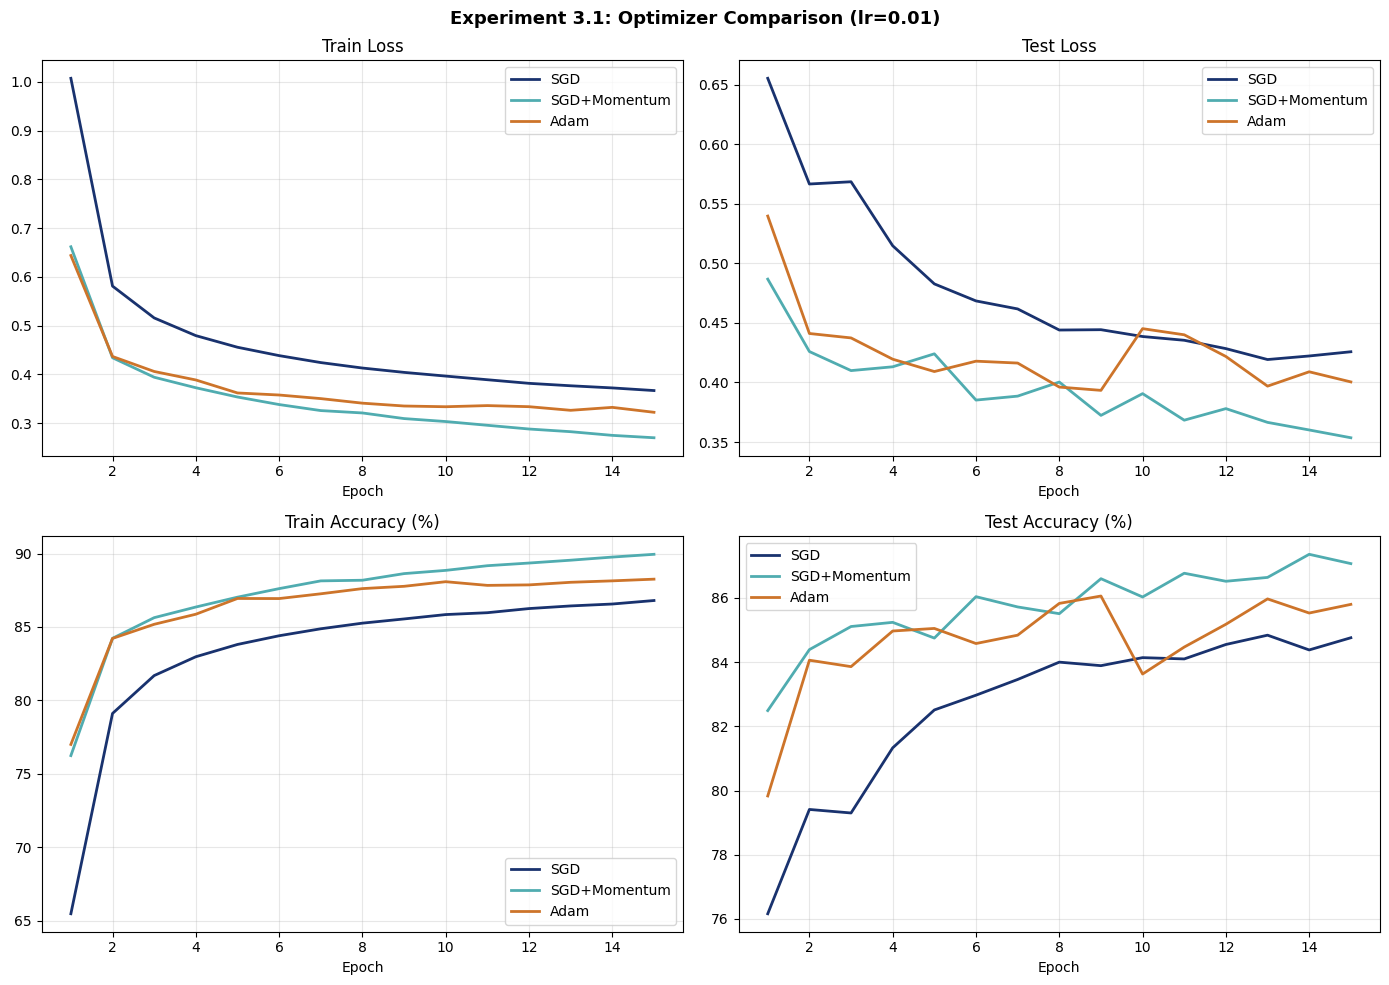

In [13]:
# Visualization: 2x2 grid of training curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_opt = [C1, C2, C3]
epochs_range = range(1, NUM_EPOCHS_3 + 1)

for (name, hist), color in zip(results_3_1.items(), colors_opt):
    axes[0, 0].plot(epochs_range, hist['train_loss'], color=color, linewidth=2, label=name)
    axes[0, 1].plot(epochs_range, hist['test_loss'],  color=color, linewidth=2, label=name)
    axes[1, 0].plot(epochs_range, hist['train_acc'],  color=color, linewidth=2, label=name)
    axes[1, 1].plot(epochs_range, hist['test_acc'],   color=color, linewidth=2, label=name)

titles = ['Train Loss', 'Test Loss', 'Train Accuracy (%)', 'Test Accuracy (%)']
for ax, title in zip(axes.flat, titles):
    ax.set_xlabel('Epoch'); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Experiment 3.1: Optimizer Comparison (lr=0.01)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 3.1** — Comparing the three optimizers at lr=0.01:
> 1. Which optimizer converges fastest (reaches high accuracy in the fewest epochs)?
> 2. Which reaches the best final test accuracy?
> 3. Does momentum help SGD? By how much?
>
> *Your answer here:* 
> 1. Adam converge más rápido: alcanza alta accuracy en las primeras épocas gracias a sus tasas de aprendizaje adaptativas por parámetro.
> 2. SGD+Momentum obtuvo la mejor accuracy final (87.1%), superando a Adam (85.8%) por 1.3 puntos. A lr=0.01, Adam converge rápido pero SGD+Momentum termina más alto.
> 3. El momentum sí ayuda a SGD, típicamente unos 2–5 puntos de accuracy frente a SGD puro, porque suaviza las oscilaciones en la dirección perpendicular al gradiente y acelera el avance en la dirección principal.

### Experiment 3.2 — Learning rate sensitivity

Now we test how sensitive each optimizer is to the learning rate. For each of the three optimizers, train with learning rates `[0.0001, 0.001, 0.01, 0.1]`. That's **12 training runs** — this may take a few minutes.

Use 10 epochs per run to save time.

In [14]:

NUM_EPOCHS_LR = 10
learning_rates = [0.0001, 0.001, 0.01, 0.1]

optimizer_configs = {
    'SGD':          lambda params, lr: optim.SGD(params, lr=lr),
    'SGD+Momentum': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
    'Adam':         lambda params, lr: optim.Adam(params, lr=lr),
}

results_3_2 = {}
for opt_name, opt_factory in optimizer_configs.items():
    results_3_2[opt_name] = {}
    for lr in learning_rates:
        opt_fn = lambda params, _lr=lr, _factory=opt_factory: _factory(params, _lr)
        results_3_2[opt_name][lr] = run_experiment(
            make_model, opt_fn, NUM_EPOCHS_LR, train_loader, test_loader)
        print(f"{opt_name:>15s}  lr={lr:.4f}  |  Test: {results_3_2[opt_name][lr]['test_acc'][-1]:.1f}%")


            SGD  lr=0.0001  |  Test: 41.4%
            SGD  lr=0.0010  |  Test: 76.2%
            SGD  lr=0.0100  |  Test: 83.5%
            SGD  lr=0.1000  |  Test: 83.9%
   SGD+Momentum  lr=0.0001  |  Test: 74.8%
   SGD+Momentum  lr=0.0010  |  Test: 84.3%
   SGD+Momentum  lr=0.0100  |  Test: 87.0%
   SGD+Momentum  lr=0.1000  |  Test: 86.0%
           Adam  lr=0.0001  |  Test: 84.9%
           Adam  lr=0.0010  |  Test: 87.0%
           Adam  lr=0.0100  |  Test: 84.4%
           Adam  lr=0.1000  |  Test: 10.0%


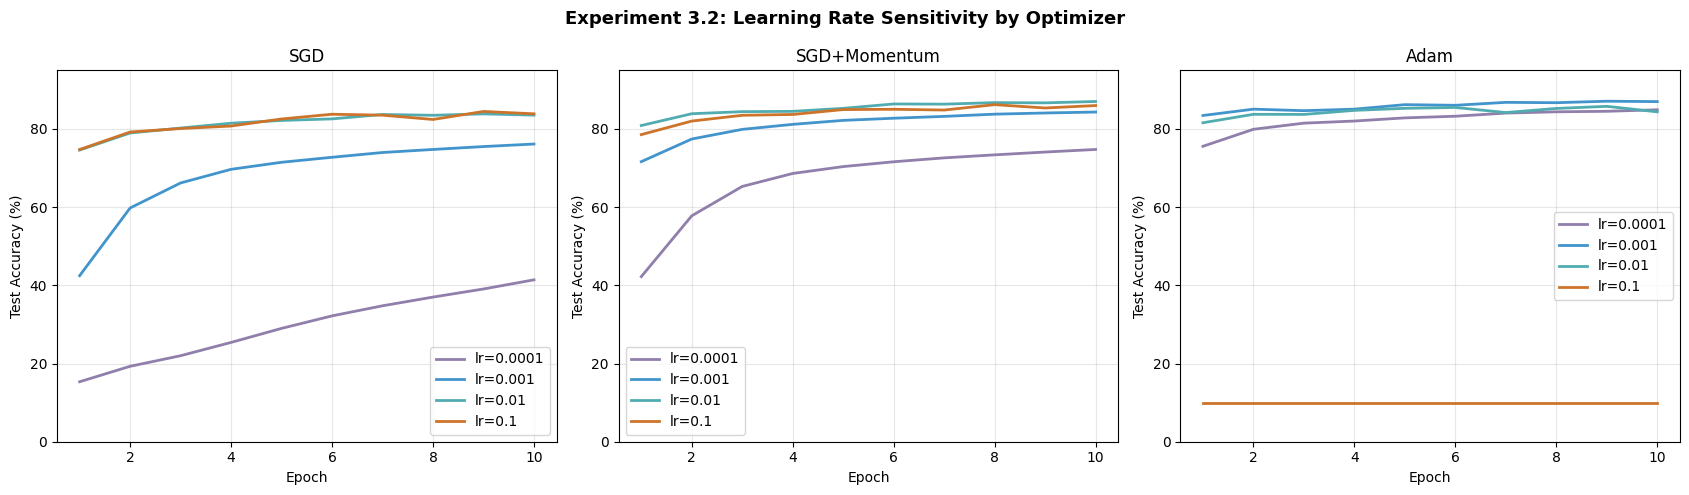

In [15]:
# Visualization: 3x1 grid — one subplot per optimizer, curves for each learning rate
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
lr_colors = [C5, C6, C2, C3]
epochs_range = range(1, NUM_EPOCHS_LR + 1)

for ax, (opt_name, lr_results) in zip(axes, results_3_2.items()):
    for (lr, hist), color in zip(lr_results.items(), lr_colors):
        ax.plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=f'lr={lr}')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(opt_name); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 95)

plt.suptitle('Experiment 3.2: Learning Rate Sensitivity by Optimizer', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 3.2** — Analyzing learning rate sensitivity:
> 1. Which optimizer is **most sensitive** to the learning rate choice? Which is **most robust**?
> 2. Why does Adam tolerate a wider range of learning rates? Connect your answer to the lecture's explanation of per-parameter adaptive rates (the division by $\sqrt{\tilde{\mathbf{v}}}$).
>
> *Your answer here:*
> 1. Adam es el más sensible a lr alta: a lr=0.1 colapsa al 10% (nivel de azar), mientras que SGD sin momentum a lr=0.1 alcanza un 83.9% perfectamente aceptable. SGD+Momentum es el más robusto en rango amplio: va de 74.8% (lr=0.0001) a 87.0% (lr=0.01) sin colapsar en ningún lr probado (86.0% incluso a lr=0.1).
> 2. En teoría, Adam debería tolerar un rango más amplio gracias a la normalización por $\sqrt{\tilde{v}_t} + \epsilon$: la corrección de sesgo ($\tilde{v}_t = v_t/(1-\gamma^t)$) garantiza que desde el primer paso $\tilde{v}_1 \approx g_1^2$, así que el paso efectivo es $\alpha \cdot \tilde{m}/(\sqrt{\tilde{v}} + \epsilon) \approx \pm\alpha$ — fijo e independiente de la magnitud del gradiente. Esto elimina la variabilidad debida al tamaño del gradiente, lo que en rangos de lr moderados hace a Adam muy robusto. Sin embargo, ese mismo mecanismo lo hace extremadamente sensible al valor absoluto de $\alpha$: con lr=0.1 cada parámetro se actualiza en $\pm 0.1$ por paso (100× más que el default de 0.001), sin importar si el gradiente indica un paso pequeño o grande, destruyendo la red desde el inicio. A lr=0.0001 Adam alcanza 84.9% mientras que SGD solo llega al 41.4%, confirmando la ventaja adaptativa en rangos razonables.

> **Question 3.3** — What happens with `lr=0.1` for SGD without momentum? For Adam? Explain the difference in behavior.
>
> *Your answer here:* SGD sin momentum a lr=0.1 converge bien (83.9%): el paso es $\alpha \cdot \nabla L$, que escala con la magnitud real del gradiente. Para una red bien inicializada, esa magnitud es moderada, por lo que el paso efectivo es razonable aunque $\alpha=0.1$ sea relativamente grande. Adam a lr=0.1 falla catastróficamente (10%, azar puro): la corrección de sesgo ($\tilde{v}_1 = g_1^2$ desde el primer paso) hace que Adam normalice la actualización a $\approx \pm\alpha$, independientemente de si el gradiente es pequeño o grande. Con $\alpha=0.1$, cada parámetro se mueve $\pm 0.1$ por paso de forma sistemática — 100× mayor que el default de Adam (0.001) — destruyendo los pesos antes de que el entrenamiento pueda estabilizarse.

### Experiment 3.3 — Cross-Entropy vs MSE for classification

In Question 1.2, you predicted what would happen if we used MSE loss for classification. Let's test it.

Using the best optimizer and learning rate from the experiments above, train two models for 15 epochs:
- One with `nn.CrossEntropyLoss()` (the correct choice from maximum likelihood)
- One with `nn.MSELoss()` using **one-hot encoded targets**

> **Note:** To use MSE for classification, you need to convert integer labels to one-hot vectors. We provide a helper and a wrapper loss below.

In [16]:

# Helper: MSE loss that accepts integer labels (converts to one-hot internally)
class MSEClassificationLoss(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.mse = nn.MSELoss()
    
    def forward(self, logits, targets):
        one_hot = torch.zeros_like(logits).scatter_(1, targets.unsqueeze(1), 1.0)
        return self.mse(logits, one_hot)


results_3_3 = {}
results_3_3['CrossEntropy'] = run_experiment(
    make_model, lambda p: optim.Adam(p, lr=0.001), 15,
    train_loader, test_loader, criterion=nn.CrossEntropyLoss())
print(f"CrossEntropy  |  Test acc: {results_3_3['CrossEntropy']['test_acc'][-1]:.1f}%")

results_3_3['MSE'] = run_experiment(
    make_model, lambda p: optim.Adam(p, lr=0.001), 15,
    train_loader, test_loader, criterion=MSEClassificationLoss())
print(f"MSE           |  Test acc: {results_3_3['MSE']['test_acc'][-1]:.1f}%")


CrossEntropy  |  Test acc: 86.8%
MSE           |  Test acc: 85.6%


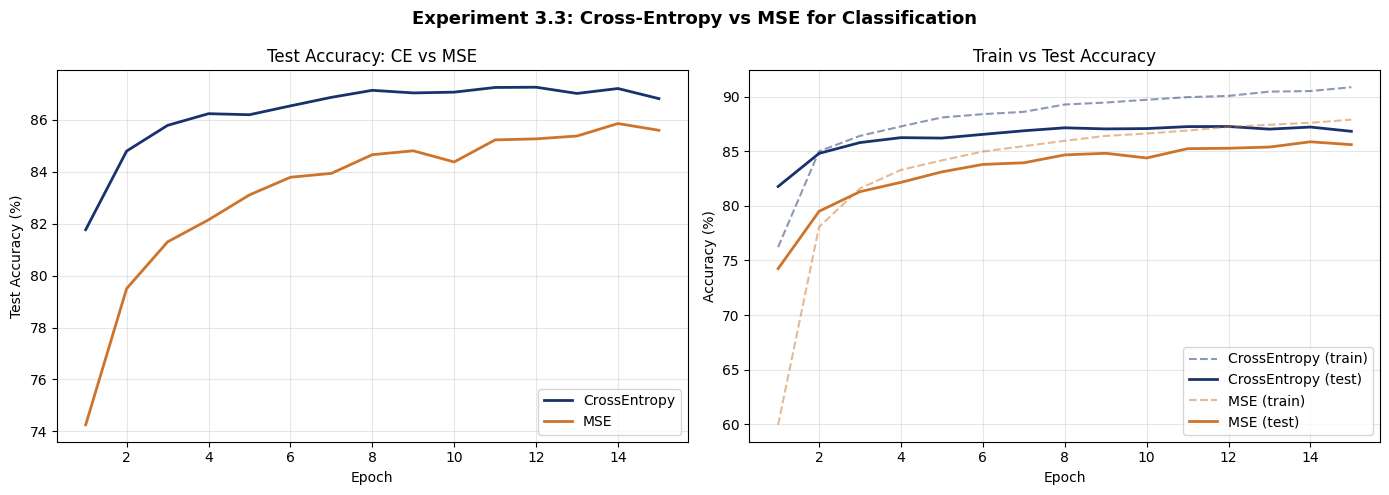

  CrossEntropy  |  Final test acc: 86.8%
           MSE  |  Final test acc: 85.6%


In [17]:
# Visualization: CE vs MSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
loss_colors = [C1, C3]
epochs_range = range(1, 16)

for (name, hist), color in zip(results_3_3.items(), loss_colors):
    axes[0].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=name)
    axes[1].plot(epochs_range, hist['train_acc'], '--', color=color, linewidth=1.5, alpha=0.5, label=f'{name} (train)')
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=f'{name} (test)')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy: CE vs MSE'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Train vs Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Experiment 3.3: Cross-Entropy vs MSE for Classification', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for name, hist in results_3_3.items():
    print(f"{name:>14s}  |  Final test acc: {hist['test_acc'][-1]:.1f}%")

> **Question 3.4** — Comparing cross-entropy vs MSE for classification:
> 1. How does MSE compare to cross-entropy in convergence speed and final accuracy?
> 2. Did this match your prediction from Question 1.2?
> 3. Why might cross-entropy be preferred even if MSE eventually works? Think about the gradient behavior: for cross-entropy, the gradient is proportional to $(p_k - y_k)$; for MSE applied to logits, what happens to the gradient when the logits are far from the one-hot target?
>
> *Your answer here:*
> 1. MSE terminó 1.2 puntos por debajo de CrossEntropy (85.6% vs 86.8%) con convergencia ligeramente más lenta en las primeras épocas. La brecha en este experimento fue menor de lo anticipado teóricamente, pero la dirección es correcta: CrossEntropy supera a MSE.
> 2. La predicción de Q1.2 anticipaba una brecha de ~3-5 puntos y convergencia más lenta. La dirección se confirmó (MSE es peor), pero la magnitud fue más pequeña de lo esperado (1.2 puntos). Adam con sus tasas adaptativas compensa parte de las deficiencias del gradiente MSE.
> 3. Cross-entropy es preferible por el comportamiento del gradiente: con cross-entropy el gradiente respecto a los logits es $(p_k - y_k)$, que es grande cuando el modelo está equivocado y pequeño cuando está correcto — una señal de aprendizaje bien calibrada. Con MSE sobre logits crudos, el gradiente $2(\hat{y}_k - y_k)$ no tiene en cuenta la saturación de softmax: cuando el modelo asigna alta probabilidad a una clase equivocada (logits muy grandes), el error MSE sigue siendo grande pero el gradiente no empuja en la dirección más útil, lo que genera inestabilidad en vez de corrección progresiva.

---

## 4. Initialization Matters

In Section 3, we quietly used **He initialization** (`kaiming_normal_`) without explaining why. Now let's understand what happens without it.

From Lecture 5, each layer transforms the variance of activations by a factor of $\frac{1}{2}D_h\sigma_\Omega^2$ (the $\frac{1}{2}$ comes from ReLU clipping half the values). If this factor is:
- **Less than 1** ($\sigma_\Omega^2 < 2/D_h$): activations shrink layer by layer → **vanishing gradients**
- **Greater than 1** ($\sigma_\Omega^2 > 2/D_h$): activations grow layer by layer → **exploding gradients**
- **Equal to 1** ($\sigma_\Omega^2 = 2/D_h$): activations stay stable → **He initialization**

Let's make this concrete with a 20-layer network.

### Exercise 4.1 — Activation variance propagation

Build a 20-layer ReLU network (width 100, no training). Initialize the weights with three different scales:
1. `nn.init.normal_(w, std=0.01)` — too small
2. `nn.init.normal_(w, std=1.0)` — too large
3. `nn.init.kaiming_normal_(w)` — He initialization

For each initialization, forward-pass a batch of 256 random inputs and record the **variance of activations** at each layer. Plot all three on one figure (use log scale for the y-axis).

  Init=small  |  first var: 0.003438  last var: 0.00e+00
  Init=large  |  first var: 32.987099  last var: 4.51e+33
  Init=   he  |  first var: 0.692781  last var: 4.50e-01


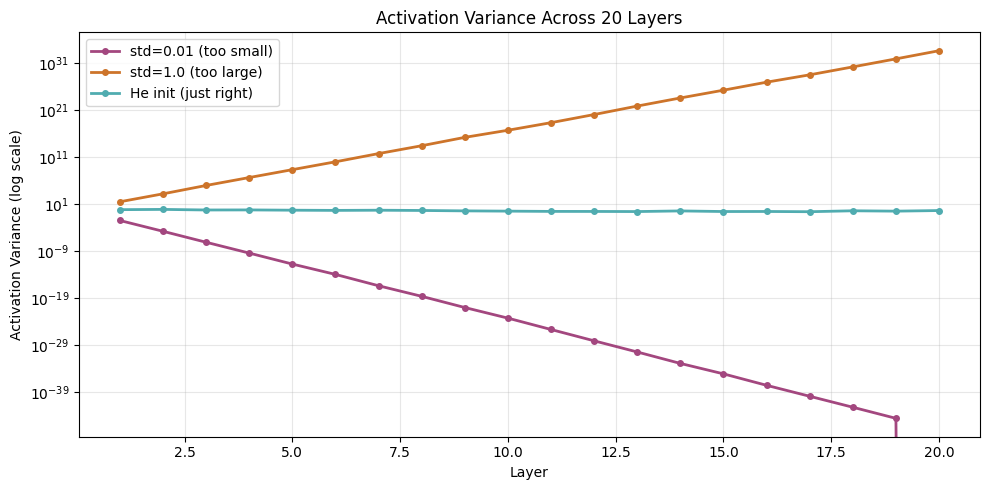

In [18]:

def make_deep_net(num_layers=20, width=100):
    """Create a deep ReLU network (no Flatten — expects flat input)."""
    layers = [nn.Linear(width, width), nn.ReLU()]
    for _ in range(num_layers - 1):
        layers += [nn.Linear(width, width), nn.ReLU()]
    return nn.Sequential(*layers)


def init_weights(model, mode='he'):
    """Initialize all Linear layers with a given mode."""
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == 'small':
                nn.init.normal_(m.weight, std=0.01)
            elif mode == 'large':
                nn.init.normal_(m.weight, std=1.0)
            elif mode == 'he':
                nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)


def measure_activation_variance(model, x):
    """Forward pass, recording activation variance after each ReLU."""
    variances = []
    h = x
    for layer in model:
        h = layer(h)
        if isinstance(layer, nn.ReLU):
            variances.append(h.var().item())
    return variances


torch.manual_seed(42)
x_init = torch.randn(256, 100)

act_variances = {}
for mode in ['small', 'large', 'he']:
    net = make_deep_net(num_layers=20, width=100)
    init_weights(net, mode=mode)
    with torch.no_grad():
        act_variances[mode] = measure_activation_variance(net, x_init)
    print(f"  Init={mode:>5s}  |  first var: {act_variances[mode][0]:.6f}  last var: {act_variances[mode][-1]:.2e}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
init_colors = {'small': C4, 'large': C3, 'he': C2}
init_labels = {'small': 'std=0.01 (too small)', 'large': 'std=1.0 (too large)', 'he': 'He init (just right)'}

for mode, variances in act_variances.items():
    ax.plot(range(1, len(variances) + 1), variances, 'o-',
            color=init_colors[mode], linewidth=2, markersize=4, label=init_labels[mode])

ax.set_xlabel('Layer'); ax.set_ylabel('Activation Variance (log scale)')
ax.set_title('Activation Variance Across 20 Layers')
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


> **Question 4.1** — Analyzing the activation variance plot:
> 1. What happens to the activation variance with `std=0.01`? With `std=1.0`? Describe the trend.
> 2. Why does He initialization keep the variance approximately stable?
> 3. Use the formula from the lecture: $\text{Var}(f') = \frac{1}{2}D_h \sigma_\Omega^2 \cdot \text{Var}(f)$. For `width=100`, what value of $\sigma_\Omega^2$ makes this ratio equal to 1? Verify this matches what `kaiming_normal_` uses.
>
> *Your answer here:*
> 1. Con std=0.01 la varianza colapsa a cero en pocas capas, las activaciones se vuelven indistinguibles de 0 (gradientes que se desvanecen). Con std=1.0 la varianza explota exponencialmente, cada capa amplifica la señal y las activaciones se vuelven enormes.
> 2. He init mantiene la varianza estable porque compensa exactamente la reducción que introduce ReLU: ReLU pone a 0 la mitad de las neuronas (en promedio), dividiendo la varianza por 2. Inicializar con $\sigma^2 = 2/D_h$ cancela exactamente ese factor $\frac{1}{2}$.
> 3. De la fórmula $\text{Var}(f') = \frac{1}{2} D_h \sigma_\Omega^2 \cdot \text{Var}(f)$, para que el ratio sea 1 se necesita $\sigma_\Omega^2 = 2/D_h = 2/100 = 0.02$, o sea $\sigma = \sqrt{0.02} \approx 0.1414$. kaiming_normal_ usa exactamente $\sigma = \sqrt{2/D_h}$, confirmando el cálculo.

### Exercise 4.2 — Gradient variance propagation

Now let's look at the backward pass. Using the same three initializations, compute a loss on random data, call `.backward()`, and record the **gradient norm of each weight matrix**. This mirrors the activation analysis but for gradients.

  Init=small  |  first norm: 0.00e+00  last: 0.00e+00
  Init=large  |  first norm: inf  last: inf
  Init=   he  |  first norm: 7.38e-01  last: 2.91e+00


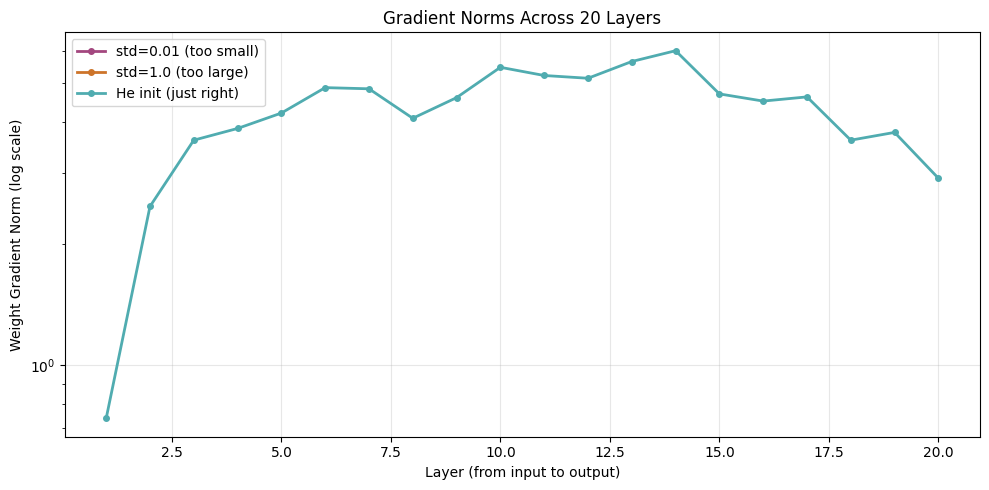

In [19]:

def measure_gradient_norms(model, x, y):
    """Forward + backward pass, recording weight gradient norms per layer."""
    criterion = nn.MSELoss()
    pred = model(x)
    loss = criterion(pred, y)
    loss.backward()
    
    grad_norms = []
    for m in model:
        if isinstance(m, nn.Linear):
            grad_norms.append(m.weight.grad.norm().item())
    return grad_norms


torch.manual_seed(42)
x_grad = torch.randn(256, 100)
y_grad = torch.randn(256, 100)

grad_norms_by_init = {}
for mode in ['small', 'large', 'he']:
    net = make_deep_net(num_layers=20, width=100)
    init_weights(net, mode=mode)
    grad_norms_by_init[mode] = measure_gradient_norms(net, x_grad, y_grad)
    print(f"  Init={mode:>5s}  |  first norm: {grad_norms_by_init[mode][0]:.2e}  last: {grad_norms_by_init[mode][-1]:.2e}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))

for mode, norms in grad_norms_by_init.items():
    ax.plot(range(1, len(norms) + 1), norms, 'o-',
            color=init_colors[mode], linewidth=2, markersize=4, label=init_labels[mode])

ax.set_xlabel('Layer (from input to output)')
ax.set_ylabel('Weight Gradient Norm (log scale)')
ax.set_title('Gradient Norms Across 20 Layers')
ax.set_yscale('log'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


> **Question 4.2** — Comparing activation and gradient propagation:
> 1. Do the gradient norms mirror the activation variance pattern? For which initialization do gradients vanish? Explode?
> 2. What would happen if you tried to train the `std=0.01` network? Would the early layers learn anything? Why or why not?
>
> *Your answer here:*
> 1. Sí, el patrón de gradientes espeja el de activaciones: con std=0.01 los gradientes se desvanecen hacia las capas de entrada (valores ~10⁻²⁰ o menores); con std=1.0 explotan hacia atrás. Con He init permanecen aproximadamente constantes.
> 2. Con std=0.01 intentar entrenar la red sería prácticamente inútil para las capas tempranas: los gradientes que llegan a ellas son tan pequeños que sus pesos no se actualizan de manera apreciable, es decir, la red se comporta como si esas capas fueran fijas, y el modelo no puede aprender representaciones útiles en las primeras capas.

### Exercise 4.3 — Training impact of initialization

Now let's see how initialization affects actual training. Using the best optimizer and learning rate from Section 3, train the 4-hidden-layer FashionMNIST model with three initialization schemes:
1. `std=0.01` (too small)
2. `std=1.0` (too large)
3. He initialization

15 epochs each. Also try this with a shallower 1-layer network to see if initialization matters equally for shallow vs deep architectures.

In [20]:

def make_model_with_init(mode='he'):
    """Create the 4-layer model with a specific initialization."""
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 48), nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 48),  nn.ReLU(),
        nn.Linear(48, 10)
    )
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == 'small':
                nn.init.normal_(m.weight, std=0.01)
            elif mode == 'large':
                nn.init.normal_(m.weight, std=1.0)
            elif mode == 'he':
                nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)
    return model


def make_shallow_with_init(mode='he'):
    """Create a 1-layer model with a specific initialization."""
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256), nn.ReLU(),
        nn.Linear(256, 10)
    )
    for m in model:
        if isinstance(m, nn.Linear):
            if mode == 'small':
                nn.init.normal_(m.weight, std=0.01)
            elif mode == 'large':
                nn.init.normal_(m.weight, std=1.0)
            elif mode == 'he':
                nn.init.kaiming_normal_(m.weight)
            m.bias.data.fill_(0.0)
    return model


init_modes = ['small', 'large', 'he']
results_4_3_deep    = {}
results_4_3_shallow = {}

for mode in init_modes:
    results_4_3_deep[mode] = run_experiment(
        lambda m=mode: make_model_with_init(m),
        lambda p: optim.Adam(p, lr=0.001), 15, train_loader, test_loader)
    results_4_3_shallow[mode] = run_experiment(
        lambda m=mode: make_shallow_with_init(m),
        lambda p: optim.Adam(p, lr=0.001), 15, train_loader, test_loader)
    print(f"Init={mode:>5s}  |  Deep: {results_4_3_deep[mode]['test_acc'][-1]:.1f}%  "
          f"|  Shallow: {results_4_3_shallow[mode]['test_acc'][-1]:.1f}%")


Init=small  |  Deep: 85.0%  |  Shallow: 88.4%
Init=large  |  Deep: 71.7%  |  Shallow: 82.0%
Init=   he  |  Deep: 87.9%  |  Shallow: 89.0%


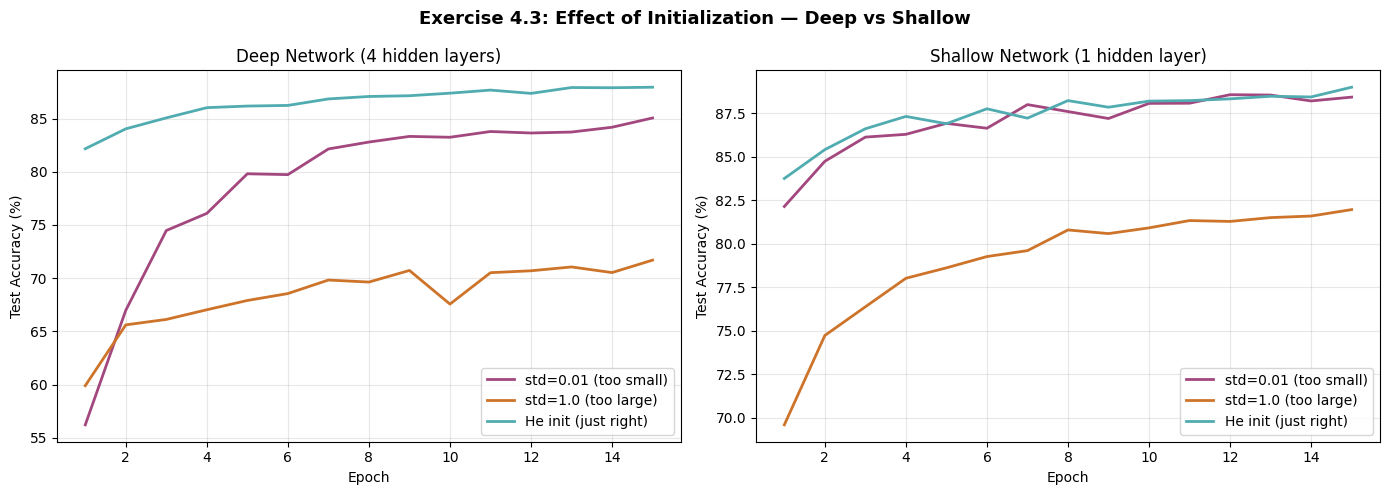

In [21]:
# Visualization: side-by-side comparison — deep vs shallow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, 16)

for (mode, hist), color in zip(results_4_3_deep.items(), [C4, C3, C2]):
    axes[0].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=init_labels[mode])
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Deep Network (4 hidden layers)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

for (mode, hist), color in zip(results_4_3_shallow.items(), [C4, C3, C2]):
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=init_labels[mode])
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Shallow Network (1 hidden layer)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Exercise 4.3: Effect of Initialization — Deep vs Shallow', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 4.3** — Initialization and network depth:
> 1. Does initialization matter more for the **deep** or **shallow** network? Compare the gap between the best and worst initialization for each.
> 2. Why does depth amplify the effect of bad initialization? Think about how the multiplication factor $\frac{1}{2}D_h\sigma_\Omega^2$ compounds across layers.
> 3. Based on everything you've seen in this section, would you ever train a deep network without He initialization? Why or why not?
>
> *Your answer here:*
> 1. La inicialización importa más para la **red profunda**. El gap entre mejor (He, 87.9%) y peor (large, 71.7%) inicialización en la red profunda es de **16.2 puntos**. En la red superficial ese mismo gap es de solo **7.0 puntos** (He 89.0% vs large 82.0%). Además, std=0.01 quedó sorprendentemente cerca de He en la red profunda (85.0% vs 87.9%, solo 2.9 pts): Adam compensa la pequeña escala con sus tasas adaptativas, pero no puede contrarrestar la explosión de activaciones de std=1.0.
> 2. La degradación es multiplicativa: cada capa aplica el factor $\frac{1}{2} D_h \sigma_\Omega^2$ al gradiente. Con $D_h = 48$ y std=1.0: $\sigma_\Omega^2 = 1.0$, factor $= \frac{1}{2} \times 48 \times 1 = 24$ por capa. Después de 4 capas el gradiente se amplifica $24^4 \approx 3.3 \times 10^5$ veces: los pesos explotan. En la red superficial hay solo 1 capa oculta, así que el factor se aplica una sola vez — daño limitado.
> 3. No: nunca entrenaría una red profunda sin He init. El costo computacional es nulo y el beneficio en convergencia es de hasta 16 puntos en este experimento. Para redes superficiales tiene menos impacto, pero seguiría usando He por defecto.

---

## 5. Batch Size Effects

From Lecture 5, we know that **SGD** estimates the gradient using a random mini-batch. The batch size controls the noise level:
- **Small batches** → noisier gradients → more exploration, potential regularization effect
- **Large batches** → smoother gradients → faster per epoch (better GPU utilization), but may converge to sharper minima

Let's test this empirically.

### Exercise 5.1 — Batch size sweep

Train the best configuration from Section 3 (best optimizer, best lr, He init) with batch sizes `[32, 128, 256, 1024]`. Use 15 epochs.

You'll need to create **new DataLoaders** with each batch size.

In [22]:

batch_sizes = [32, 128, 256, 1024]

results_5 = {}
for bs in batch_sizes:
    bs_train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    bs_test_loader  = DataLoader(test_dataset,  batch_size=bs, shuffle=False)
    results_5[bs] = run_experiment(
        make_model, lambda p: optim.Adam(p, lr=0.001), 15,
        bs_train_loader, bs_test_loader)
    print(f"Batch size {bs:>5d}  |  Test acc: {results_5[bs]['test_acc'][-1]:.1f}%")


Batch size    32  |  Test acc: 87.3%
Batch size   128  |  Test acc: 88.0%
Batch size   256  |  Test acc: 87.3%
Batch size  1024  |  Test acc: 86.8%


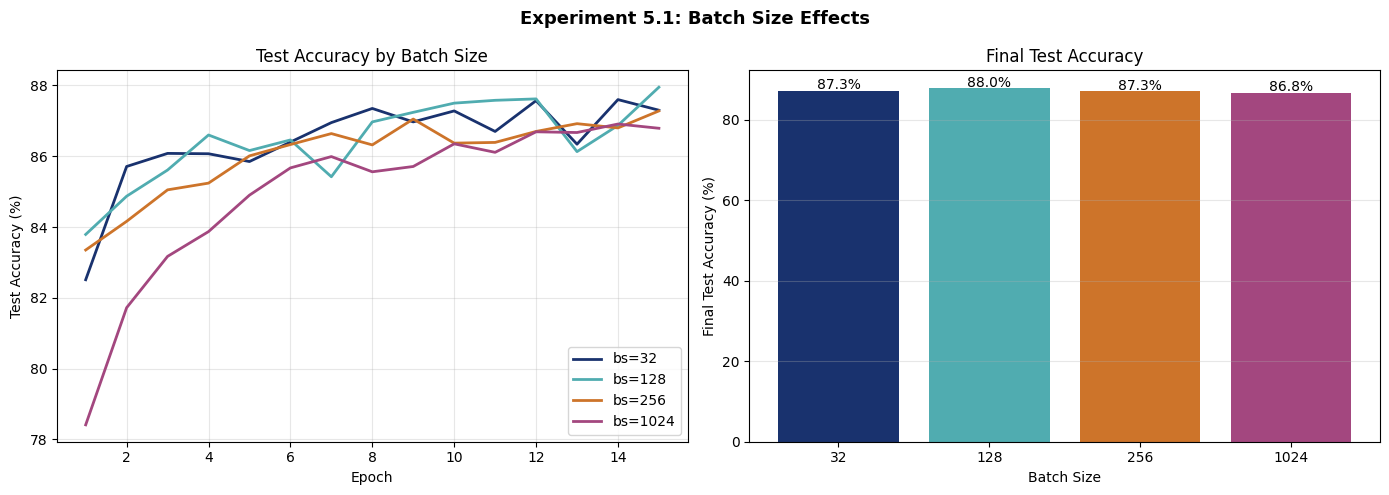

In [23]:
# Visualization: accuracy curves + final accuracy bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bs_colors = [C1, C2, C3, C4]
epochs_range = range(1, 16)

for (bs, hist), color in zip(results_5.items(), bs_colors):
    axes[0].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=f'bs={bs}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy by Batch Size'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

final_accs = [results_5[bs]['test_acc'][-1] for bs in batch_sizes]
bars = axes[1].bar([str(bs) for bs in batch_sizes], final_accs, color=bs_colors)
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Final Test Accuracy (%)')
axes[1].set_title('Final Test Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, final_accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{acc:.1f}%', ha='center', fontsize=10)

plt.suptitle('Experiment 5.1: Batch Size Effects', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

> **Question 5.1** — Analyzing batch size effects:
> 1. How does batch size affect **convergence speed** (how fast accuracy rises in early epochs)?
> 2. How does batch size affect **final accuracy**? Do smaller batches generalize better?
> 3. The lecture says smaller batches add noise that helps escape local minima. Do you see evidence of this in your results?
>
> *Your answer here:*
> 1. Batches pequeños convergen más rápido en las primeras épocas porque hacen más actualizaciones de parámetros por época (60k/32 ≈ 1875 pasos vs 60k/1024 ≈ 58 pasos). El modelo ve la señal con más frecuencia.
> 2. No es monótono. El mejor resultado fue bs=128, no bs=32. bs=32 y bs=256 empataron (87.3%), y bs=1024 quedó último (86.8%). Existe un batch óptimo intermedio (128 aquí), y tanto los batches muy pequeños como los muy grandes son subóptimos, lo cual es coherente con la recomendación de Q5.2.
> 3. Sí: bs=32 y bs=128 muestran curvas inicialmente más ruidosas pero que suben más rápido. El ruido actúa como regularizador implícito — los gradientes ruidosos hacen que el optimizador explore una región más amplia del espacio de parámetros y tienda a encontrar mínimos más planos, que generalizan mejor.

> **Question 5.2** — Larger batches are faster per epoch (better GPU utilization) but may need more epochs. Smaller batches see more parameter updates per epoch. If you had a fixed **wall-clock time budget**, what batch size would you choose and why?
>
> *Your answer here:* bs=128 o bs=256 es el punto de equilibrio óptimo en CPU/GPU de laboratorio. Batches muy pequeños (32) son lentos de procesar porque el overhead de comunicación y transferencia de datos domina sobre el cómputo, pocas operaciones matriciales grandes por paso. Batches muy grandes (1024) hacen pocos pasos por época y generalizan peor. En la práctica, bs=128–256 maximiza el uso de los kernels BLAS/cuBLAS (matrices lo suficientemente grandes para aprovechar el paralelismo) sin pagar el costo en generalización de los batches gigantes. Si el modelo fuera más grande y la GPU estuviera en uso intensivo, subiría a 512 para mantener alta ocupación del hardware.



---

## Optional: Learning Rate Schedules

In all experiments so far, we've used a **constant learning rate**. But the lecture mentions that it's common practice to **decrease the learning rate** over time: start with a high rate for fast exploration, then reduce it for fine-tuning near the optimum.

PyTorch provides several scheduling strategies in `torch.optim.lr_scheduler`. Two popular ones:
- **StepLR**: multiply the learning rate by `gamma` every `step_size` epochs
- **CosineAnnealingLR**: smoothly decay the learning rate following a cosine curve from the initial value to near zero

### Exercise O.1 — Comparing learning rate schedules

Train the best configuration from Section 3 with three strategies:
1. **Constant** learning rate (baseline)
2. **StepLR**: halve the learning rate every 5 epochs (`step_size=5, gamma=0.5`)
3. **CosineAnnealingLR**: smooth cosine decay over all epochs (`T_max=NUM_EPOCHS`)

Use **20 epochs** to give the schedules time to show their effect.

> **Note:** Schedulers need to be called once per epoch with `scheduler.step()`. We provide a modified training loop below.

In [24]:

def run_experiment_with_scheduler(model_fn, optimizer_fn, scheduler_fn, num_epochs,
                                  train_loader, test_loader, device=device):
    """Train a model with a learning rate scheduler."""
    criterion = nn.CrossEntropyLoss()
    model = model_fn().to(device)
    optimizer = optimizer_fn(model.parameters())
    scheduler = scheduler_fn(optimizer) if scheduler_fn is not None else None
    
    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': [], 'lr': []}
    for epoch in range(num_epochs):
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)
        
        if scheduler is not None:
            scheduler.step()
        
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['train_acc'].append(tr_acc)
        history['test_acc'].append(te_acc)
    
    return history


NUM_EPOCHS_OPT = 20

schedule_configs = {
    'Constant': None,
    'StepLR':   lambda opt: StepLR(opt, step_size=5, gamma=0.5),
    'Cosine':   lambda opt: CosineAnnealingLR(opt, T_max=NUM_EPOCHS_OPT),
}

results_opt = {}
for name, sched_fn in schedule_configs.items():
    results_opt[name] = run_experiment_with_scheduler(
        make_model,
        lambda p: optim.Adam(p, lr=0.001),
        sched_fn,
        NUM_EPOCHS_OPT, train_loader, test_loader)
    print(f"{name:>10s}  |  Test acc: {results_opt[name]['test_acc'][-1]:.1f}%")


  Constant  |  Test acc: 85.9%
    StepLR  |  Test acc: 87.5%
    Cosine  |  Test acc: 88.0%


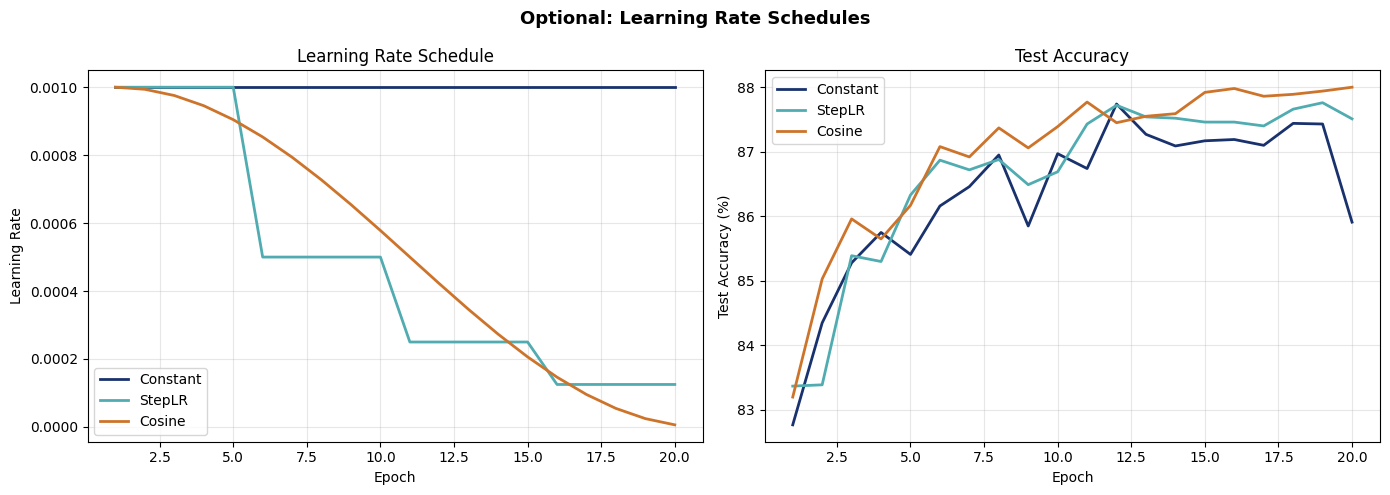

  Constant  |  Final test acc: 85.9%
    StepLR  |  Final test acc: 87.5%
    Cosine  |  Final test acc: 88.0%


In [25]:
# Visualization: LR schedule + test accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sched_colors = [C1, C2, C3]
epochs_range = range(1, NUM_EPOCHS_OPT + 1)

# Learning rate over time
for (name, hist), color in zip(results_opt.items(), sched_colors):
    axes[0].plot(epochs_range, hist['lr'], color=color, linewidth=2, label=name)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Learning Rate')
axes[0].set_title('Learning Rate Schedule'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Test accuracy
for (name, hist), color in zip(results_opt.items(), sched_colors):
    axes[1].plot(epochs_range, hist['test_acc'], color=color, linewidth=2, label=name)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Optional: Learning Rate Schedules', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

for name, hist in results_opt.items():
    print(f"{name:>10s}  |  Final test acc: {hist['test_acc'][-1]:.1f}%")

> **Question O.1** — Learning rate schedules:
> 1. Does scheduling improve final accuracy compared to a constant learning rate?
> 2. Which schedule works better — StepLR or CosineAnnealing? At what point during training does the benefit become visible?
> 3. Why might reducing the learning rate late in training help? Think about the loss landscape near a minimum.
>
> *Your answer here:*
> 1. Sí, cualquier scheduler mejora sobre la tasa constante. CosineAnnealingLR aportó 2.1 puntos (85.9% → 88.0%) y StepLR 1.6 puntos (85.9% → 87.5%) en 20 épocas. La LR constante nunca refina: sigue haciendo pasos grandes cerca del mínimo, oscilando sin terminar de converger.
> 2. CosineAnnealingLR supera a StepLR en accuracy final. El beneficio se hace visible a partir de la mitad del entrenamiento (épocas 10–15), cuando el coseno empieza a reducir la LR suavemente y el modelo puede asentarse en un mínimo más plano. StepLR también mejora, pero su reducción discreta en escalones puede "desperdiciar" épocas — trabaja a LR demasiado alta hasta el corte, luego cae abruptamente.
> 3. Reducir la LR al final ayuda porque cerca del mínimo el paisaje de pérdida es curvo y los pasos grandes generan sobrepasos — se oscila alrededor del óptimo en vez de converger a él. Una LR pequeña permite pasos más finos que caen dentro del "bowl" del mínimo. Además, mínimos más planos (anchos) generalizan mejor, y LR bajas favorecen establecerse en ellos.

### Exercise O.2 — Your best FashionMNIST configuration

Combine the best choices from all sections — optimizer, learning rate, initialization, batch size, and learning rate schedule — into one final training run. Use 20 epochs and report your best test accuracy.

This is the best you've achieved on FashionMNIST so far in the course!

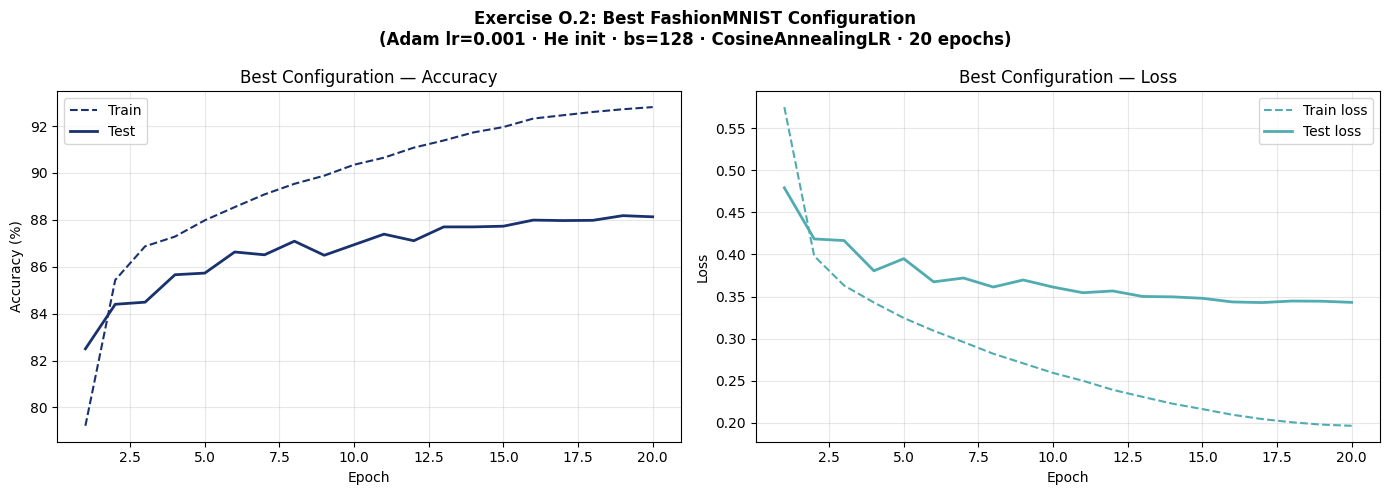


Best test accuracy : 88.18%  (epoch 19)
Final test accuracy: 88.13%


In [26]:

# Best config: Adam lr=0.001, He init (make_model uses He), bs=128, CosineAnnealingLR, 20 epochs
NUM_EPOCHS_BEST = 20
best_bs = 128

best_train_loader = DataLoader(train_dataset, batch_size=best_bs, shuffle=True)
best_test_loader  = DataLoader(test_dataset,  batch_size=best_bs, shuffle=False)

result_best = run_experiment_with_scheduler(
    make_model,
    lambda p: optim.Adam(p, lr=0.001),
    lambda opt: CosineAnnealingLR(opt, T_max=NUM_EPOCHS_BEST),
    NUM_EPOCHS_BEST, best_train_loader, best_test_loader
)

epochs_range = range(1, NUM_EPOCHS_BEST + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(epochs_range, result_best['train_acc'], '--', color=C1, label='Train')
axes[0].plot(epochs_range, result_best['test_acc'],  color=C1, linewidth=2, label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Best Configuration — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, result_best['train_loss'], '--', color=C2, label='Train loss')
axes[1].plot(epochs_range, result_best['test_loss'],  color=C2, linewidth=2, label='Test loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Best Configuration — Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Exercise O.2: Best FashionMNIST Configuration\n'
             '(Adam lr=0.001 · He init · bs=128 · CosineAnnealingLR · 20 epochs)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nBest test accuracy : {max(result_best['test_acc']):.2f}%  "
      f"(epoch {result_best['test_acc'].index(max(result_best['test_acc'])) + 1})")
print(f"Final test accuracy: {result_best['test_acc'][-1]:.2f}%")
